# Lab 7
#### Author: Esraaj Sarkar Gupta
#### Date: 1st March, 2026

In [11]:
# ---- Imports ---- #

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score

print("Imports completed...")

Imports completed...


In [12]:
# ---- Load Data ---- #

# Loading the datasets
odi_data = pd.read_csv('virat_kohli_odi_innings_data.csv')
t20_data = pd.read_csv('virat_kohli_t20i_innings_data.csv')
test_data = pd.read_csv('virat_kohli_test_innings_data.csv')

# Preview
display(odi_data.head())
display(t20_data.head())

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date,Odi No
0,12,33,22,1,0,54.54,2,lbw,1,v Sri Lanka,Dambulla,18/08/08,ODI # 2742
1,37,82,67,6,0,55.22,2,caught,2,v Sri Lanka,Dambulla,20/08/08,ODI # 2745
2,25,40,38,4,0,65.78,1,run out,1,v Sri Lanka,Colombo (RPS),24/08/08,ODI # 2750
3,54,87,66,7,0,81.81,1,bowled,1,v Sri Lanka,Colombo (RPS),27/08/08,ODI # 2755
4,31,45,46,3,1,67.39,1,lbw,2,v Sri Lanka,Colombo (RPS),29/08/08,ODI # 2756


,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date,T20I No
0,26,30,21,3,1,123.8,5,not out,2,v Zimbabwe,Harare,12/06/10,T20I # 182
1,DNB,-,-,-,-,-,-,-,2,v Zimbabwe,Harare,13/06/10,T20I # 183
2,28,28,19,5,0,147.36,1,bowled,1,v South Africa,Durban,09/01/11,T20I # 196
3,14,15,12,2,0,116.66,3,caught,1,v West Indies,Port of Spain,04/06/11,T20I # 200
4,4,5,5,0,0,80,4,caught,1,v England,Manchester,31/08/11,T20I # 204


In [13]:
# ---- Concat Data ---- #

# Some Data Cleaning -- convert all text -> NaN
odi_runs_clean = pd.to_numeric(odi_data['Runs'], errors='coerce')
t20_runs_clean = pd.to_numeric(t20_data['Runs'], errors='coerce')
test_runs_clean = pd.to_numeric(test_data['Runs'], errors='coerce')

odi_sr_clean = pd.to_numeric(odi_data['SR'], errors='coerce')
t20_sr_clean = pd.to_numeric(t20_data['SR'], errors='coerce')
test_sr_clean = pd.to_numeric(test_data['SR'], errors='coerce')

"""
Concat data on runs, strike rates, and grounds from all
three datasets.
"""
runs = np.concatenate((odi_runs_clean, t20_runs_clean, test_runs_clean))
strike_rates = np.concatenate((odi_sr_clean, t20_sr_clean, test_sr_clean))

#ground = np.concatenate((odi_data['Ground'], t20_data['Ground'], test_data['Ground']))

# ---- Store Match-Type Data ---- #
# NOTE: np.repeat() creates a list where the chosen string is repeated `n` times.
match_type = np.concatenate((
    np.repeat("ODI", len(odi_data)), 
    np.repeat("T20", len(t20_data)), 
    np.repeat("TEST", len(test_data))
))

In [14]:
# ---- Create Concat DataFrame ---- #

data_cricketer = pd.DataFrame({
    'Runs': runs, 
    'SR': strike_rates, 
    'match_type': match_type
})

# Cleaning: Drop rows within missing data
data_cricketer.dropna(inplace=True)

# Preview
display(data_cricketer.head())
print(f"\nTotal rows in dataset: {len(data_cricketer)}")

,Runs,SR,match_type
0,12.0,54.54,ODI
1,37.0,55.22,ODI
2,25.0,65.78,ODI
3,54.0,81.81,ODI
4,31.0,67.39,ODI



Total rows in dataset: 531


In [15]:
# ---- Features and Target Feature Split ---- #

X = data_cricketer[['Runs', 'SR']]
Y = data_cricketer['match_type']

In [16]:
# ---- 70 - 30 Train-Test Data Split ---- #
(x_train, x_test,
 y_train, y_test) = train_test_split(X, Y,
                                     test_size=0.30,
                                     random_state=19) # Seed with 19 for no particular reason

In [17]:
# ---- SVC Model ---- # (The Bulk of this Lab Assignment)

# Create the model
svm_model = SVC(
    kernel='poly', # Polynomial Kernel -- Allowing non-linear seperation (using curves)
    degree=6 # Recommended degree of polynomial
    )

# Fit the model
svm_model.fit(x_train, y_train)

# Make  predictions
y_pred = svm_model.predict(x_test)

# And proudly let everyone know that
print("Model training and prediction complete.")

Model training and prediction complete.


--- Model Performance Metrics ---
Accuracy: 0.731
Balanced Accuracy: 0.713


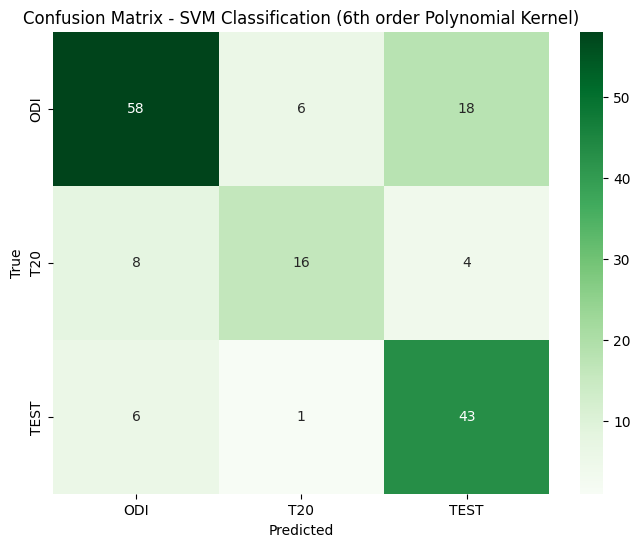

Classification Report:
              precision    recall  f1-score   support

         ODI       0.81      0.71      0.75        82
         T20       0.70      0.57      0.63        28
        TEST       0.66      0.86      0.75        50

    accuracy                           0.73       160
   macro avg       0.72      0.71      0.71       160
weighted avg       0.74      0.73      0.73       160



In [18]:
# ---- Performance Metrics ---- #

print("--- Model Performance Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")

# Confusion Matrix + Plotting

plt.figure(figsize=(8, 6))

conf_matrix = confusion_matrix(y_test, y_pred) # Confused?

# Create the heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d',   # format: decimal integer `d` 
            cmap='Greens',                      # I like the colour green
            xticklabels=svm_model.classes_,     # Use the SVM Classes passed to it from Y
            yticklabels=svm_model.classes_)

plt.title('Confusion Matrix - SVM Classification (6th order Polynomial Kernel)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report

print("Classification Report:")
print(classification_report(y_test, y_pred))

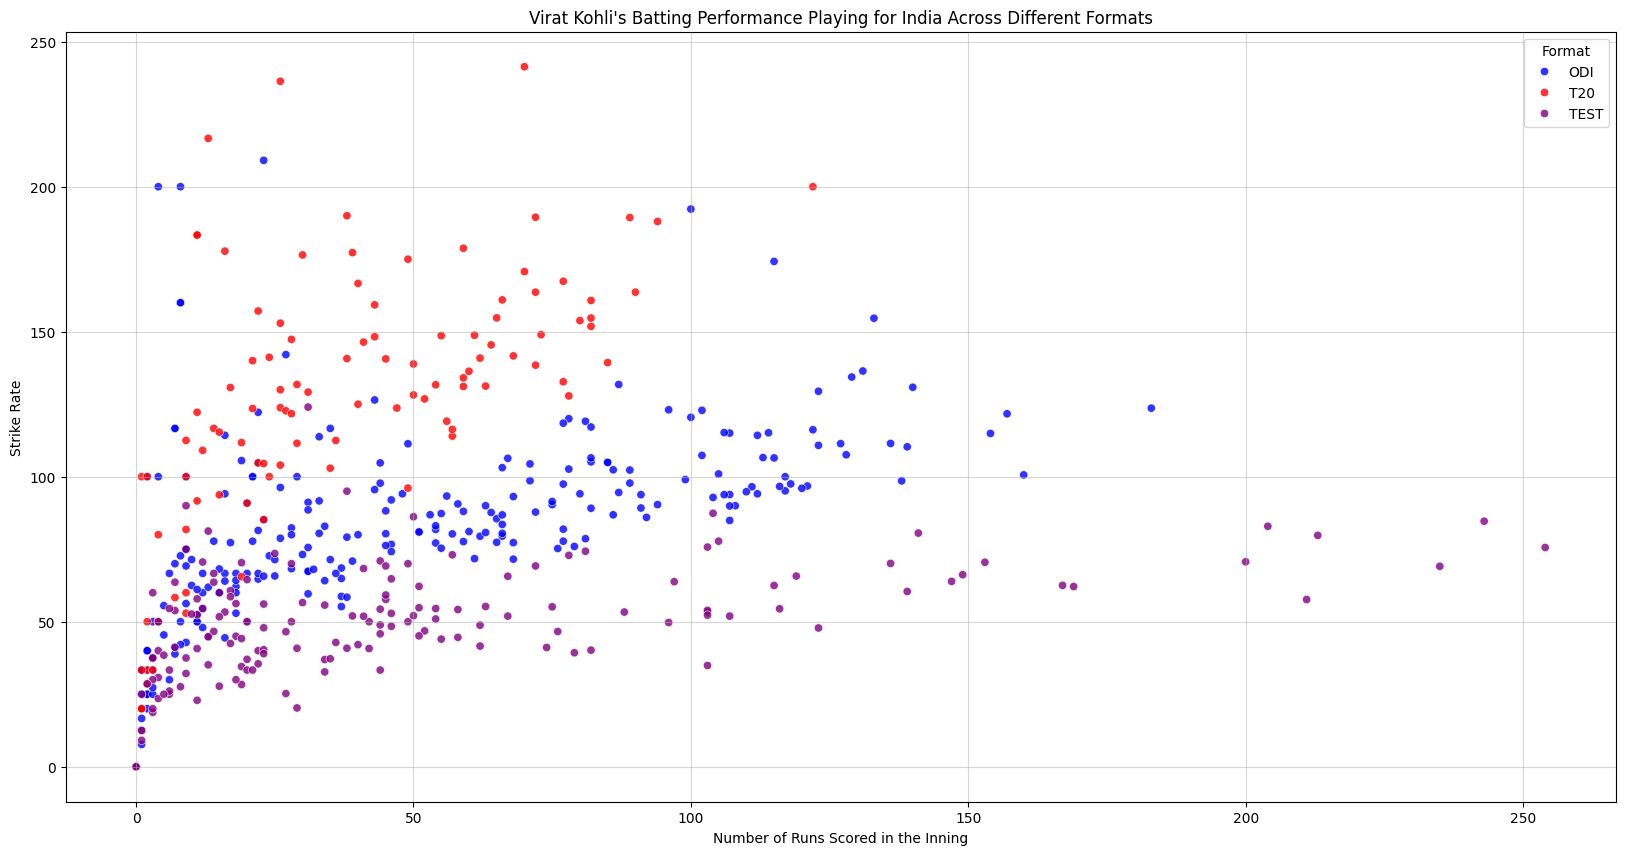

In [19]:
# ---- Performance Scatter Plot ---- #

# The Plot in Scatter Plot
plt.figure(figsize=(20, 10))

# Select colour codes
palette = {
    "ODI": "blue",
    "T20": "red",
    "TEST": "purple"
    } # How pretty

# Main scatter plot

sns.scatterplot(
    data = data_cricketer, 
    x = 'Runs', 
    y = 'SR', 
    hue = 'match_type', 
    palette = palette,
    alpha = 0.8
)

plt.title("Virat Kohli's Batting Performance Playing for India Across Different Formats")
plt.xlabel('Number of Runs Scored in the Inning')
plt.ylabel('Strike Rate')

plt.legend(title='Format')

plt.grid(True, alpha=0.5)
plt.show()

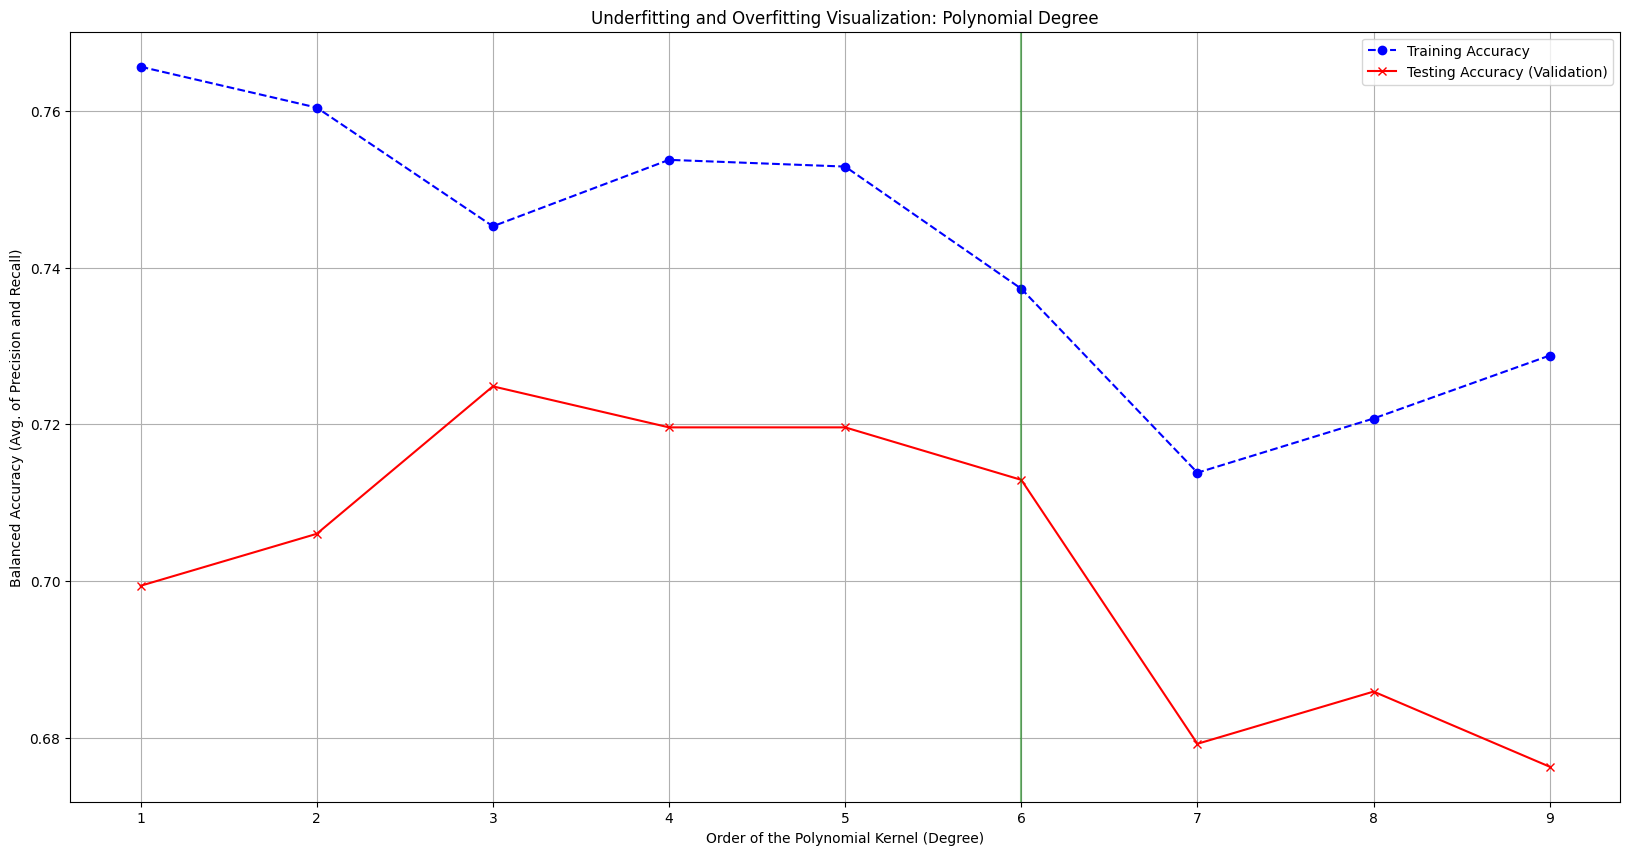

In [ ]:
# ---- Overfitting with greater Polynomial Degrees ---- #

degrees = np.arange(1, 10)

# Accuracy lists
train_accuracies : list = list([])
test_accuracies : list = list([])

for degree in degrees:
    model = SVC(kernel='poly', degree=degree)
    model.fit(x_train, y_train)
    
    # Training Accuracy
    y_train_pred = model.predict(x_train)
    train_acc = balanced_accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_acc)
    
    # Test Accuracy
    y_test_pred = model.predict(x_test)
    test_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_accuracies.append(test_acc)


# Plot accuracies
plt.figure(figsize=(20, 10))
plt.plot(degrees, train_accuracies, marker='o', label='Training Accuracy', color='blue', linestyle='--')
plt.plot(degrees, test_accuracies, marker='x', label='Testing Accuracy', color='red')

plt.title('Underfitting and Overfitting Visualization: Polynomial Degree')

plt.xlabel('Order of the Polynomial Kernel (Degree)')
plt.ylabel('Balanced Accuracy (Avg. of Precision and Recall)')

plt.legend()
plt.grid(True)

# Plot veritcal axis line on 6
plt.axvline(x=6, color='green', # Such a lovely colour
            alpha=0.5, label='Lab Recommended Degree')

plt.show()

# Report

### Question 1

Support Vectors are the data points that lie closest to the decision boundary (decision hyperplane). These are the only points that determine the position and the orientation of the hyperplane.

Since SVM is reliant only on this set of critical points instead of on all the data points (or any metric reliant on the entire dataset such as the mean), SVM  is a ML method much less prone to outliers.

### Question 2

A hard-margin SVM requires every single training point to be correctly classified and <b> strictly </b> within class boundaries. This works for perfectly linearly seperable data.

A soft-margin SVM, however does allow some training points to violate the margin, thus being misclassified. This may achieve a robust boundary that generalizes better to unseen data.

### Question 3

SVM handles non-linear boundaries by using the Kernel trick (used here). The input data is mathematically mapped to a higher dimensional space which may allow the classes to be linearly seperable. In higher dimensions, SVM may find a hyperplane that when projected back into the original feature space, correctly seperates the non-linearly seperated classes.

### Question 4

The gamma parameter in SVM determines the influence of a single training data point. Lower gamma values correspond to greater reach of the datum point. Thus, a low gamma point can lead to underfitting since the model is allowed to ignore the true itricate shape of the data.

In contrast a higher gamma value reduces the influence of a single data point, leading to overfitting sicne the decison boundary is too relieant on individual data points, attempting to capture each one.

### Question 5

A standard SVM is a binary classifier. It handles (like it does here) multiple class problems by breaking them down into multiple binary sub-problems. This is done using the OvR (One vs Rest) approach, where each class is compared against all the other (here, 2) classes combined.

Alternatively, one may utilize a OvO (One vs One) approach where each classifier is trained for every possible pair of classes and the final label is then chosen by a majority vote.

